# E-Commerce Marketing Analysis

*By Maria Ilnitska | Portfolio Project*


1. **Business Problem**

An e-commerce company collects large amounts of data related to customer purchases, product sales, and marketing campaigns. However, management lacks clear visibility into:

- which products and categories generate the most revenue

- how customer behavior impacts sales performance

- which marketing channels are most effective at converting users into customers

- how customer segments contribute to overall revenue

Without structured analysis, it is difficult to make data-driven decisions about marketing investments, product strategy, and customer retention.

2. **Project Objectives**

The main objectives of this analysis are to:

- analyze overall sales performance and revenue distribution

- identify top-performing products and product categories

- examine customer purchasing behavior and repeat purchase patterns

- evaluate marketing campaign performance using key marketing metrics

- measure conversion efficiency across marketing channels

- identify opportunities to improve customer retention and marketing effectiveness

# Loading Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data

In [5]:
orders = pd.read_csv("../sales_data/orders_data.csv")
customers = pd.read_csv("../sales_data/customers_data.csv")
products = pd.read_csv("../sales_data/products_data.csv")
campaigns = pd.read_csv("../sales_data/campaigns_data.csv")

# Data Overview

In [6]:
orders.head()

,order_id,customer_id,product_id,order_date,quantity,order_status,payment_method,total_price
0,1,119,372,2024-07-03,4,Completed,Apple Pay,408.16
1,2,313,294,2024-08-04,3,Completed,Google Pay,197.94
2,3,264,253,2023-04-26,4,Completed,PayPal,329.24
3,4,207,143,2023-08-27,1,Completed,Apple Pay,81.00
4,5,95,250,2023-12-01,3,Completed,Google Pay,630.06


In [7]:
customers.head()

,customer_id,first_name,last_name,email,country,city,signup_date,customer_segment
0,1,Name1,Surname1,user1@example.com,Australia,Rome,2024-09-14,New
1,2,Name2,Surname2,user2@example.com,Spain,New York,2024-09-07,New
2,3,Name3,Surname3,user3@example.com,Netherlands,New York,2024-11-13,New
3,4,Name4,Surname4,user4@example.com,France,Madrid,2024-04-04,Returning
4,5,Name5,Surname5,user5@example.com,Australia,Rome,2023-12-22,New


In [8]:
products.head()

,product_id,product_name,category,price,cost,stock_quantity,supplier
0,1,Product_1,Books,144.68,124.05,375,SupplierB
1,2,Product_2,Clothing,134.54,248.77,21,SupplierA
2,3,Product_3,Sports,127.25,230.06,882,SupplierC
3,4,Product_4,Home,453.60,173.34,312,SupplierA
4,5,Product_5,Books,128.53,286.95,996,SupplierA


In [9]:
campaigns.head()

,campaign_id,campaign_name,campaign_type,start_date,end_date,budget,clicks,conversions
0,1,Campaign_1,Social Media,2023-09-14,2025-02-06,9898.90,9877,4360
1,2,Campaign_2,Affiliate,2023-08-23,2025-03-12,1873.98,36431,217
2,3,Campaign_3,Email,2024-05-14,2025-01-04,5923.80,21068,2507
3,4,Campaign_4,Social Media,2023-10-16,2025-03-22,6827.88,37909,4200
4,5,Campaign_5,Email,2024-05-24,2024-10-10,18929.89,11392,1893


# Orders Data Check

In [10]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        500 non-null    int64  
 1   customer_id     500 non-null    int64  
 2   product_id      500 non-null    int64  
 3   order_date      500 non-null    str    
 4   quantity        500 non-null    int64  
 5   order_status    500 non-null    str    
 6   payment_method  500 non-null    str    
 7   total_price     500 non-null    float64
dtypes: float64(1), int64(4), str(3)
memory usage: 31.4 KB


In [11]:
orders.describe()

,order_id,customer_id,product_id,quantity,total_price
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,262.602000,261.720000,2.484000,486.776920
std,144.481833,139.779111,144.577241,1.119039,368.492034
min,1.000000,1.000000,2.000000,1.000000,12.880000
25%,125.750000,146.500000,143.000000,1.000000,202.187500
50%,250.500000,268.000000,268.000000,3.000000,379.545000
75%,375.250000,385.500000,385.000000,3.000000,705.645000
max,500.000000,500.000000,500.000000,4.000000,1589.000000


In [12]:
orders.isnull().sum()

order_id          0
customer_id       0
product_id        0
order_date        0
quantity          0
order_status      0
payment_method    0
total_price       0
dtype: int64

In [13]:
orders.shape

(500, 8)

# Customers Data Check

In [14]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       500 non-null    int64
 1   first_name        500 non-null    str  
 2   last_name         500 non-null    str  
 3   email             500 non-null    str  
 4   country           500 non-null    str  
 5   city              500 non-null    str  
 6   signup_date       500 non-null    str  
 7   customer_segment  500 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.4 KB


In [15]:
customers.describe()

,customer_id
count,500.000000
mean,250.500000
std,144.481833
min,1.000000
25%,125.750000
50%,250.500000
75%,375.250000
max,500.000000


In [16]:
customers.isnull().sum()

customer_id         0
first_name          0
last_name           0
email               0
country             0
city                0
signup_date         0
customer_segment    0
dtype: int64

In [17]:
customers.shape

(500, 8)

# Products Data Check

In [18]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      500 non-null    int64  
 1   product_name    500 non-null    str    
 2   category        500 non-null    str    
 3   price           500 non-null    float64
 4   cost            500 non-null    float64
 5   stock_quantity  500 non-null    int64  
 6   supplier        500 non-null    str    
dtypes: float64(2), int64(2), str(3)
memory usage: 27.5 KB


In [19]:
products.describe()

,product_id,price,cost,stock_quantity
count,500.000000,500.000000,500.00000,500.00000
mean,250.500000,252.298580,152.69994,484.96200
std,144.481833,141.542824,87.70370,286.56621
min,1.000000,5.770000,3.00000,2.00000
25%,125.750000,137.712500,80.16250,238.00000
50%,250.500000,250.530000,151.68500,479.50000
75%,375.250000,372.930000,230.64750,725.00000
max,500.000000,497.740000,299.35000,996.00000


In [20]:
products.isnull().sum()

product_id        0
product_name      0
category          0
price             0
cost              0
stock_quantity    0
supplier          0
dtype: int64

In [21]:
products.shape

(500, 7)

# Campaings Data Check

In [22]:
campaigns.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_id    500 non-null    int64  
 1   campaign_name  500 non-null    str    
 2   campaign_type  500 non-null    str    
 3   start_date     500 non-null    str    
 4   end_date       500 non-null    str    
 5   budget         500 non-null    float64
 6   clicks         500 non-null    int64  
 7   conversions    500 non-null    int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 31.4 KB


In [23]:
campaigns.describe()

,campaign_id,budget,clicks,conversions
count,500.000000,500.000000,500.000000,500.00000
mean,250.500000,10008.527400,25053.204000,2523.99600
std,144.481833,5478.496192,14475.696758,1496.72674
min,1.000000,507.830000,309.000000,17.00000
25%,125.750000,5354.057500,12533.500000,1258.00000
50%,250.500000,9958.615000,25210.500000,2572.00000
75%,375.250000,14285.892500,37525.000000,3910.75000
max,500.000000,19978.640000,49910.000000,4984.00000


In [24]:
campaigns.isnull().sum()

campaign_id      0
campaign_name    0
campaign_type    0
start_date       0
end_date         0
budget           0
clicks           0
conversions      0
dtype: int64

In [25]:
campaigns.shape

(500, 8)

# Data Preparation

Businesses want to know:

• which month sells best

• which season is weak

• when to run marketing campaigns

In [26]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
campaigns["start_date"] = pd.to_datetime(campaigns["start_date"])
campaigns["end_date"] = pd.to_datetime(campaigns["end_date"])

In [27]:
# create new columns for year and month orders
orders["order_year"] = orders["order_date"].dt.year
orders["order_month"] = orders["order_date"].dt.month

In [28]:
# create new columns for year and month for customers
customers["signup_year"] = customers["signup_date"].dt.year
customers["signup_month"] = customers["signup_date"].dt.month

In [29]:
# create new columns for year and month for campaigns
campaigns["start_year"] = campaigns["start_date"].dt.year
campaigns["start_month"] = campaigns["start_date"].dt.month

campaigns["end_year"] = campaigns["end_date"].dt.year
campaigns["end_month"] = campaigns["end_date"].dt.month

# KPI Revenue

Conversion Rate (CR) = conversions ÷ clicks

Cost per Click (CPC) = budget ÷ clicks

Cost per Acquisition (CPA) = budget ÷ conversions

In [30]:
campaigns['conversion_rate'] = campaigns['conversions'] / campaigns['clicks']
campaigns['CPC'] = campaigns['budget'] / campaigns['clicks']
campaigns['CPA'] = campaigns['budget'] / campaigns['conversions']

# Handle divide-by-zero
campaigns.replace([float('inf'), -float('inf')], pd.NA, inplace=True)

,campaign_id,campaign_name,campaign_type,start_date,end_date,budget,clicks,conversions,start_year,start_month,end_year,end_month,conversion_rate,CPC,CPA
0,1,Campaign_1,Social Media,2023-09-14,2025-02-06,9898.90,9877,4360,2023,9,2025,2,0.441430,1.002217,2.270390
1,2,Campaign_2,Affiliate,2023-08-23,2025-03-12,1873.98,36431,217,2023,8,2025,3,0.005956,0.051439,8.635853
2,3,Campaign_3,Email,2024-05-14,2025-01-04,5923.80,21068,2507,2024,5,2025,1,0.118996,0.281175,2.362904
3,4,Campaign_4,Social Media,2023-10-16,2025-03-22,6827.88,37909,4200,2023,10,2025,3,0.110792,0.180112,1.625686
4,5,Campaign_5,Email,2024-05-24,2024-10-10,18929.89,11392,1893,2024,5,2024,10,0.166169,1.661683,9.999942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Campaign_496,Email,2024-03-27,2024-11-23,17290.15,7730,175,2024,3,2024,11,0.022639,2.236759,98.800857
496,497,Campaign_497,Influencer,2023-04-15,2025-05-29,11534.33,16475,4453,2023,4,2025,5,0.270288,0.700111,2.590238
497,498,Campaign_498,Affiliate,2023-05-30,2024-12-10,3566.10,41609,2906,2023,5,2024,12,0.069841,0.085705,1.227151
498,499,Campaign_499,Google Ads,2023-05-26,2025-02-07,13967.14,25318,4503,2023,5,2025,2,0.177858,0.551668,3.101741


In [31]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")

df.head()

,order_id,customer_id,product_id,order_date,quantity,order_status,payment_method,total_price,order_year,order_month,...,signup_date,customer_segment,signup_year,signup_month,product_name,category,price,cost,stock_quantity,supplier
0,1,119,372,2024-07-03,4,Completed,Apple Pay,408.16,2024,7,...,2023-02-20,Returning,2023,2,Product_372,Sports,327.88,268.55,152,SupplierC
1,2,313,294,2024-08-04,3,Completed,Google Pay,197.94,2024,8,...,2023-09-30,New,2023,9,Product_294,Beauty,107.46,172.15,186,SupplierD
2,3,264,253,2023-04-26,4,Completed,PayPal,329.24,2023,4,...,2024-04-22,Returning,2024,4,Product_253,Electronics,455.27,203.22,605,SupplierA
3,4,207,143,2023-08-27,1,Completed,Apple Pay,81.00,2023,8,...,2024-11-15,New,2024,11,Product_143,Beauty,272.69,34.29,559,SupplierB
4,5,95,250,2023-12-01,3,Completed,Google Pay,630.06,2023,12,...,2023-04-24,VIP,2023,4,Product_250,Clothing,301.49,243.90,330,SupplierA


# Sales Analysis

### Total Revenue

In [32]:
total_revenue = df["total_price"].sum()
total_orders = df["order_id"].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)

Total Revenue: 243388.45999999996
Total Orders: 500


### Revenue by Category

In [33]:
category_sales = df.groupby("category")["total_price"].sum().sort_values(ascending=False)
category_sales

category
Beauty         49690.31
Clothing       46612.80
Sports         42098.25
Books          41501.49
Electronics    32797.30
Home           30688.31
Name: total_price, dtype: float64

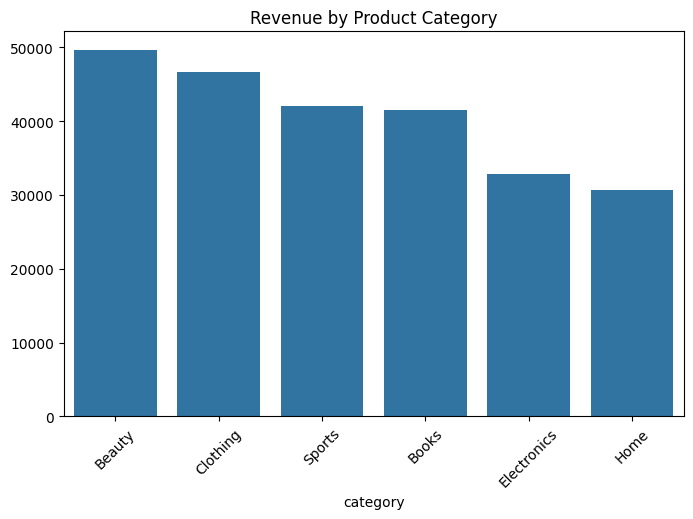

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()

### Monthly Revenue Trend

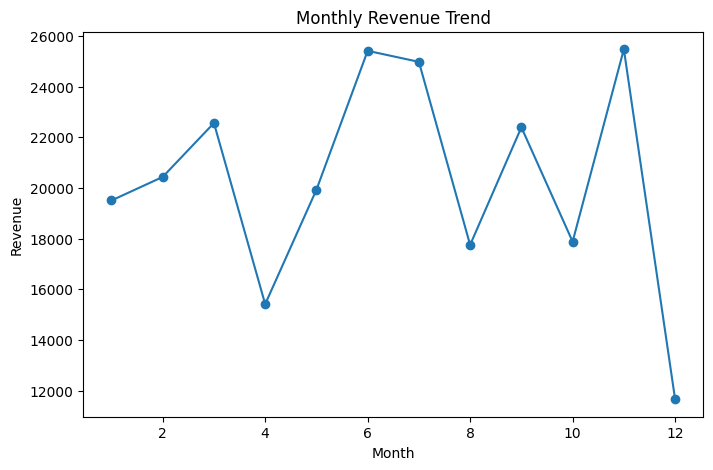

In [47]:
monthly_sales = df.groupby("order_month")["total_price"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### Top 10 Products

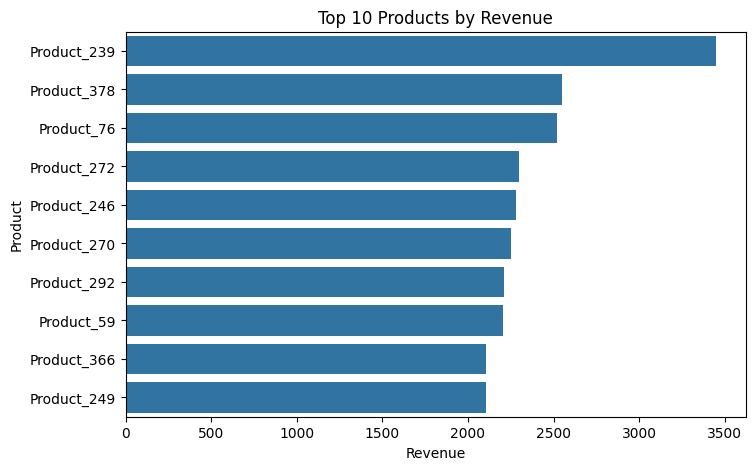

In [48]:
top_products = df.groupby("product_name")["total_price"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

# Customer Analysis

### Revenue by Customer Segment

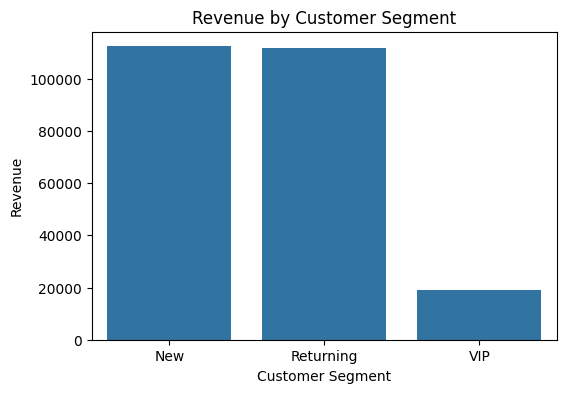

In [49]:
segment_sales = df.groupby("customer_segment")["total_price"].sum()
plt.figure(figsize=(6,4))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

### Orders Per Customer

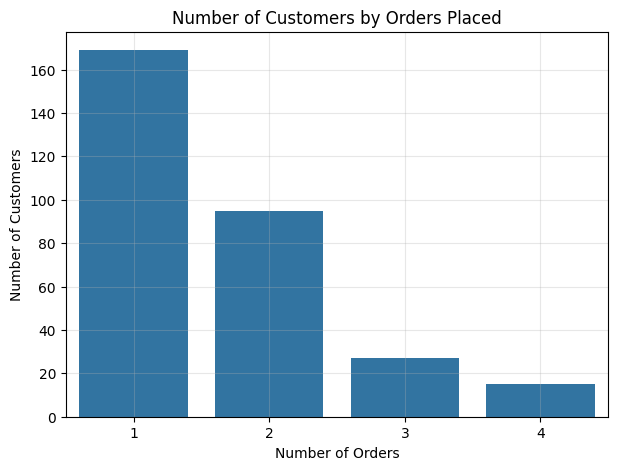

In [59]:
orders_per_customer = df.groupby("customer_id")["order_id"].count()

orders_distribution = orders_per_customer.value_counts().sort_index()

plt.figure(figsize=(7,5))

sns.barplot(
    x=orders_distribution.index,
    y=orders_distribution.values
)

plt.title("Number of Customers by Orders Placed")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.grid(alpha=0.3)

plt.show()

### Insight

The distribution of orders per customer shows that most customers make only a small number of purchases.

- Approximately 170 customers placed only 1 order, representing the largest portion of the customer base.

- Around 95 customers placed 2 orders, indicating some repeat purchasing behavior.

- A much smaller number of customers made 3 orders (about 27 customers).

- Only around 14 customers placed 4 orders, representing the most loyal segment.

Overall, the majority of customers make one or two purchases, while only a small fraction become highly repeat buyers.

### Business Implication

These results suggest that customer retention opportunities exist.

Since most customers make only a single purchase, the company could increase revenue by encouraging additional purchases through:

- loyalty or reward programs

- personalized email marketing campaigns

- targeted promotions encouraging repeat purchases

Improving repeat purchase behavior could significantly increase the lifetime value of customers.

## Revenue by Country

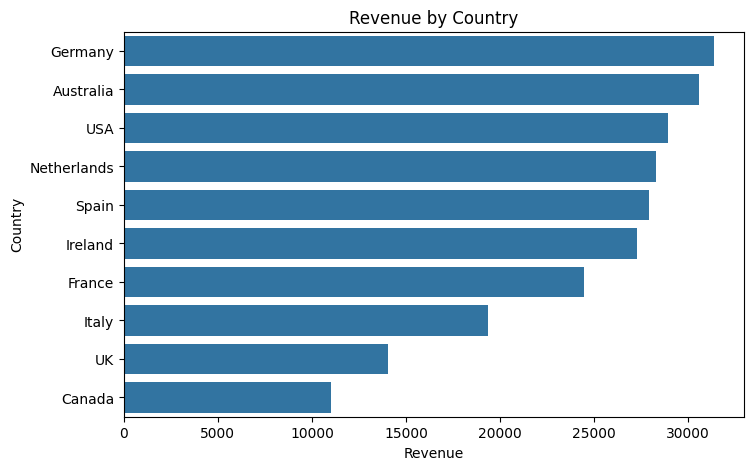

In [50]:
country_sales = df.groupby("country")["total_price"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Revenue by Country")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

### Insight

The analysis of revenue by country reveals clear differences in market performance across geographic regions.

- Germany generates the highest revenue, with approximately €31,500 in total sales.

- Australia follows closely with about €30,500 in revenue.

- The United States ranks third, contributing roughly €29,000.

- Other strong markets include the Netherlands (~€28,500) and Spain (~€28,000).

- Mid-tier revenue contributions come from Ireland (~€27,500) and France (~€24,500).

- Lower revenue levels are observed in Italy (~€19,500), the UK (~€14,000), and Canada (~€11,000).

Overall, the top five countries account for a substantial share of total revenue, indicating that a few key markets drive the majority of sales activity.

### Business Implication

The results suggest that the company should focus marketing and growth strategies on high-performing markets such as Germany, Australia, and the United States, where customer demand is strongest.

At the same time, countries with lower revenue performance, such as Canada and the UK, may represent growth opportunities where targeted marketing campaigns or localized strategies could help increase sales.

## Revenue Contribution by Customer Segment

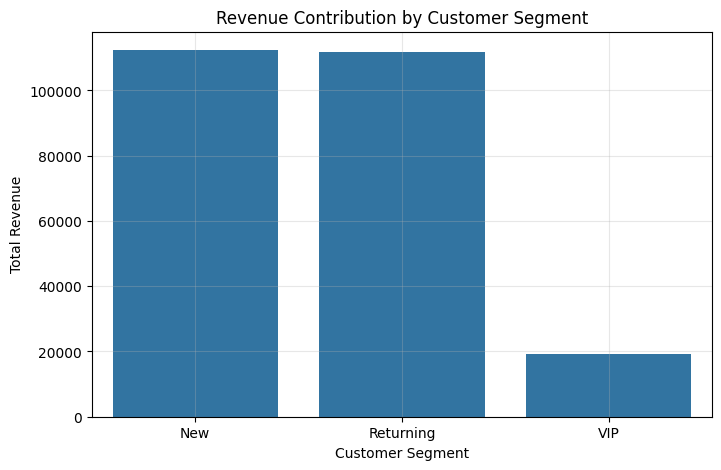

In [57]:
segment_revenue = df.groupby("customer_segment")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.grid(alpha=0.3)

plt.show()

### Insight

New and Returning customers generate the vast majority of revenue in the dataset.

- New customers contribute approximately €112,000 in total revenue.

- Returning customers generate about €110,000 in revenue.

- VIP customers contribute significantly less, with around €19,000 in total revenue.

Combined, New and Returning customers account for roughly €222,000 of revenue, representing more than 90% of total sales, while the VIP segment contributes only a small portion.

### Business Implication

The results indicate that customer acquisition and repeat purchases are the primary drivers of revenue.

This suggests that the company should:

- Continue investing in customer acquisition campaigns to attract new buyers.

- Focus on retention strategies that encourage new customers to become returning customers.

- Develop targeted programs to increase engagement among VIP customers, who currently contribute a relatively small share of total revenue.

# Campaign Performance Analysis

### Conversion Rate by Campaign Type

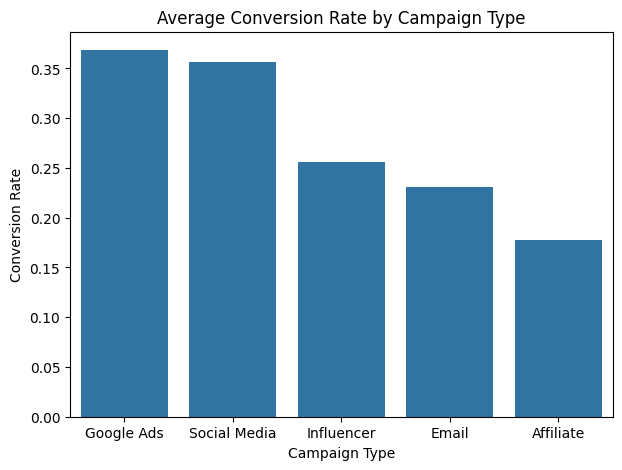

In [ ]:
campaign_type_cr = campaigns.groupby("campaign_type")["conversion_rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    x=campaign_type_cr.index,
    y=campaign_type_cr.values
)

plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Conversion Rate")

plt.show()

### Insight

The analysis of conversion rates across marketing channels shows significant differences in campaign effectiveness.

- Google Ads has the highest average conversion rate at approximately 37%.

- Social Media campaigns follow closely with a conversion rate of about 35–36%.

- Influencer campaigns achieve a moderate conversion rate of around 26%.

- Email campaigns generate a conversion rate of approximately 23%.

- Affiliate marketing performs the weakest with a conversion rate of roughly 18%.

Overall, paid advertising channels such as Google Ads and Social Media demonstrate the strongest ability to convert users into customers, significantly outperforming other campaign types.

### Business Implication

These results suggest that marketing investments should prioritize high-performing channels such as Google Ads and Social Media, which demonstrate the highest conversion efficiency.

At the same time, the company should investigate potential optimization opportunities for Affiliate and Email campaigns, as their lower conversion rates indicate less efficient customer acquisition.

Improving targeting strategies or campaign messaging in these channels could help increase their marketing performance.

### Budget vs Conversions

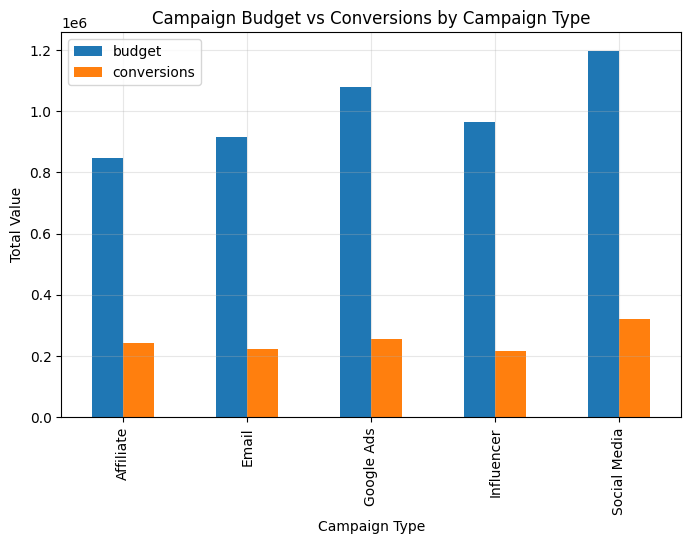

In [56]:
campaign_performance = campaigns.groupby("campaign_type")[["budget", "conversions"]].sum()

campaign_performance.plot(kind="bar", figsize=(8,5))

plt.title("Campaign Budget vs Conversions by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Total Value")

plt.grid(alpha=0.3)
plt.show()

### Insight

The comparison of campaign budgets and total conversions reveals noticeable differences in marketing efficiency across campaign types.

- Social Media campaigns receive the largest total budget (approximately €1.2M) and also generate the highest number of conversions (around 320,000).

- Google Ads campaigns represent the second largest investment with roughly €1.08M in budget, producing approximately 260,000 conversions.

- Influencer campaigns receive about €970,000 in budget, resulting in around 215,000 conversions.

- Email campaigns operate with a slightly lower budget of approximately €920,000, generating about 225,000 conversions.

- Affiliate campaigns receive the lowest budget (~€850,000) but still produce around 245,000 conversions, indicating relatively strong performance compared to their investment.

### Top Campaigns

In [46]:
top_campaigns = campaigns.sort_values("conversion_rate", ascending=False).head(10)
top_campaigns

,campaign_id,campaign_name,campaign_type,start_date,end_date,budget,clicks,conversions,start_year,start_month,end_year,end_month,conversion_rate,CPC,CPA
205,206,Campaign_206,Google Ads,2024-02-22,2025-01-08,4697.25,626,4702,2024,2,2025,1,7.511182,7.503594,0.998990
365,366,Campaign_366,Social Media,2024-03-23,2024-12-23,2632.44,527,3505,2024,3,2024,12,6.650854,4.995142,0.751053
235,236,Campaign_236,Social Media,2023-07-19,2025-03-01,14237.63,784,4977,2023,7,2025,3,6.348214,18.160242,2.860685
22,23,Campaign_23,Social Media,2023-01-08,2025-02-27,4771.65,794,4839,2023,1,2025,2,6.094458,6.009635,0.986082
368,369,Campaign_369,Google Ads,2023-11-26,2024-12-31,11604.91,899,4625,2023,11,2024,12,5.144605,12.908687,2.509170
170,171,Campaign_171,Influencer,2023-07-01,2025-04-21,19576.18,1195,4313,2023,7,2025,4,3.609205,16.381741,4.538878
159,160,Campaign_160,Influencer,2024-01-31,2024-12-16,4552.56,1260,3885,2024,1,2024,12,3.083333,3.613143,1.171830
304,305,Campaign_305,Google Ads,2023-04-02,2025-05-05,13482.80,665,2010,2023,4,2025,5,3.022556,20.274887,6.707861
69,70,Campaign_70,Google Ads,2024-02-19,2024-10-10,16348.29,309,932,2024,2,2024,10,3.016181,52.907087,17.541084
248,249,Campaign_249,Google Ads,2023-07-28,2024-10-09,12281.39,1334,3140,2023,7,2024,10,2.353823,9.206439,3.911271


# Business Insights

### Sales

Revenue is concentrated within a small number of product categories, indicating that certain product segments drive a large share of overall sales.

Top-performing products contribute a disproportionately large share of revenue, suggesting opportunities to focus marketing and inventory strategies on these high-demand items.

### Customers

Most revenue is generated by New and Returning customers, indicating that both customer acquisition and repeat purchases are the primary drivers of total sales.

The majority of customers place only one or two orders, suggesting that repeat purchasing behavior is limited and that improving customer retention could increase long-term revenue.

Certain geographic markets, such as Germany, Australia, and the United States, contribute a larger share of total revenue compared to other regions.

### Marketing

Conversion rates vary significantly across campaign types.

Some campaigns achieve much lower cost per acquisition, indicating higher marketing efficiency.